# 🔍 DefectVision — 04. PatchCore from Scratch

**Objectif** : Implémenter PatchCore sans librairie tierce pour détecter les anomalies industrielles.

**Workflow** :
```
Train (good only) → WideResNet50 features → Coreset Memory Bank
                                                      ↓
Test image → features → distance to Memory Bank → Anomaly Score → Heatmap
```

**Pourquoi PatchCore après YOLOv8 ?**
> YOLOv8 supervisé : mAP50=0.09 (trop peu de données défectueuses annotées)
> PatchCore non supervisé : entraîné uniquement sur images normales → AUROC ~99%

## 0. Setup

In [15]:
!nvidia-smi

Tue Mar 10 19:51:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
!pip install -q scikit-learn scikit-image tqdm huggingface_hub

In [17]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_BASE  = Path('/content/drive/MyDrive/defect-vision')
MVTEC_PATH  = DRIVE_BASE / 'data' / 'mvtec'
MODELS_PATH = DRIVE_BASE / 'models' / 'patchcore_bottle'
MODELS_PATH.mkdir(parents=True, exist_ok=True)

CATEGORY = 'bottle'
cat_path = MVTEC_PATH / CATEGORY

print(f'✅ MVTec   : {MVTEC_PATH}')
print(f'✅ Models  : {MODELS_PATH}')
assert cat_path.exists(), '❌ Dataset introuvable'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ MVTec   : /content/drive/MyDrive/defect-vision/data/mvtec
✅ Models  : /content/drive/MyDrive/defect-vision/models/patchcore_bottle


In [18]:
import torch
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, f1_score
from sklearn.neighbors import NearestNeighbors
import random
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch  : {torch.__version__}')
print(f'✅ Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'✅ GPU      : {torch.cuda.get_device_name(0)}')

✅ PyTorch  : 2.10.0+cu128
✅ Device   : cuda
✅ GPU      : Tesla T4


## 1. Dataset

In [19]:
# Lister les images
train_imgs  = sorted((cat_path / 'train' / 'good').glob('*.png'))
test_good   = sorted((cat_path / 'test'  / 'good').glob('*.png'))
test_defect = []
for d in sorted((cat_path / 'test').iterdir()):
    if d.is_dir() and d.name != 'good':
        test_defect += sorted(d.glob('*.png'))

# Test set complet avec labels (0=good, 1=defect)
test_imgs   = test_good   + test_defect
test_labels = [0]*len(test_good) + [1]*len(test_defect)

print(f'=== {CATEGORY} ===')
print(f'  Train (good)   : {len(train_imgs)} images → Memory Bank')
print(f'  Test good      : {len(test_good)} images')
print(f'  Test defect    : {len(test_defect)} images')
print(f'  Test total     : {len(test_imgs)} images')

=== bottle ===
  Train (good)   : 209 images → Memory Bank
  Test good      : 20 images
  Test defect    : 63 images
  Test total     : 83 images


In [20]:
# Transforms ImageNet standard
TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

def load_image(path):
    img = Image.open(path).convert('RGB')
    return TRANSFORM(img).unsqueeze(0).to(DEVICE)

print('✅ Transforms configurés')

✅ Transforms configurés


## 2. Extracteur de features (WideResNet50)

In [21]:
class FeatureExtractor(torch.nn.Module):
    """
    Extrait les features intermédiaires de WideResNet50
    depuis layer2 et layer3 (comme dans le papier PatchCore).
    """
    def __init__(self):
        super().__init__()
        backbone = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
        self.layer0 = torch.nn.Sequential(backbone.conv1, backbone.bn1,
                                          backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3

        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        f2 = self.layer2(x)   # [B, 512, 28, 28]
        f3 = self.layer3(f2)  # [B, 1024, 14, 14]
        return f2, f3

extractor = FeatureExtractor().to(DEVICE).eval()
print('✅ WideResNet50 chargé (poids ImageNet)')

# Test rapide
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    f2, f3 = extractor(dummy)
print(f'  layer2 features : {f2.shape}')
print(f'  layer3 features : {f3.shape}')

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:01<00:00, 124MB/s]


✅ WideResNet50 chargé (poids ImageNet)
  layer2 features : torch.Size([1, 512, 28, 28])
  layer3 features : torch.Size([1, 1024, 14, 14])


## 3. Extraction des patch features

In [22]:
def extract_patch_features(img_paths, desc='Extracting'):
    """
    Pour chaque image, extrait les patch features de layer2+layer3
    et les concatène après upsampling au même niveau spatial.
    Retourne un tenseur [N_patches_total, feature_dim]
    """
    all_features = []
    upsample = torch.nn.Upsample(size=(28, 28), mode='bilinear', align_corners=False)

    with torch.no_grad():
        for path in tqdm(img_paths, desc=desc):
            img = load_image(path)
            f2, f3 = extractor(img)

            # Upsample f3 vers la taille de f2
            f3_up = upsample(f3)

            # Concat sur la dimension channel
            combined = torch.cat([f2, f3_up], dim=1)  # [1, 1536, 28, 28]

            # Reshape : [28*28, 1536] = [784, 1536]
            B, C, H, W = combined.shape
            patches = combined.permute(0, 2, 3, 1).reshape(-1, C)
            all_features.append(patches.cpu())

    return torch.cat(all_features, dim=0)

print('✅ Fonction extraction prête')
print('  Dimension features : 512 (layer2) + 1024 (layer3) = 1536 par patch')
print('  Patches par image  : 28x28 = 784')

✅ Fonction extraction prête
  Dimension features : 512 (layer2) + 1024 (layer3) = 1536 par patch
  Patches par image  : 28x28 = 784


In [23]:
# Extraire les features des images d'entraînement (good only)
print('🚀 Extraction des features train...')
start = time.time()
train_features = extract_patch_features(train_imgs, desc='Train features')
print(f'\n✅ Features extraites en {time.time()-start:.1f}s')
print(f'   Shape : {train_features.shape}')  # [N_images * 784, 1536]

🚀 Extraction des features train...


Train features: 100%|██████████| 209/209 [00:15<00:00, 13.39it/s]



✅ Features extraites en 16.4s
   Shape : torch.Size([163856, 1536])


## 4. Coreset Subsampling (Memory Bank)

In [24]:
def coreset_sampling(features, ratio=0.1, seed=42):
    """
    Sélectionne un sous-ensemble représentatif des features
    par random sampling (approximation du coreset greedy).
    ratio=0.1 → garde 10% des patches.
    """
    torch.manual_seed(seed)
    n_total   = features.shape[0]
    n_select  = max(1, int(n_total * ratio))
    indices   = torch.randperm(n_total)[:n_select]
    return features[indices]

print('🚀 Construction de la Memory Bank (coreset 10%)...')
start = time.time()
memory_bank = coreset_sampling(train_features, ratio=0.1)
print(f'✅ Memory Bank construite en {time.time()-start:.1f}s')
print(f'   Patches totaux  : {train_features.shape[0]:,}')
print(f'   Memory Bank     : {memory_bank.shape[0]:,} patches ({memory_bank.shape[0]/train_features.shape[0]*100:.1f}%)')
print(f'   Taille mémoire  : {memory_bank.nbytes / 1e6:.1f} MB')

🚀 Construction de la Memory Bank (coreset 10%)...
✅ Memory Bank construite en 0.0s
   Patches totaux  : 163,856
   Memory Bank     : 16,385 patches (10.0%)
   Taille mémoire  : 100.7 MB


## 5. Scoring des anomalies

In [25]:
# Construire l'index KNN sur la Memory Bank
print('🚀 Construction index KNN...')
start = time.time()
knn = NearestNeighbors(n_neighbors=9, metric='euclidean', algorithm='ball_tree', n_jobs=-1)
knn.fit(memory_bank.numpy())
print(f'✅ Index KNN prêt en {time.time()-start:.1f}s')

def compute_anomaly_score(img_path):
    """
    Calcule le score d anomalie d une image :
    - Extrait les patch features
    - Pour chaque patch, trouve la distance au plus proche voisin dans la Memory Bank
    - Le score image = max des distances (patch le plus anormal)
    - La heatmap = carte des distances (28x28)
    """
    upsample = torch.nn.Upsample(size=(28, 28), mode='bilinear', align_corners=False)

    with torch.no_grad():
        img = load_image(img_path)
        f2, f3 = extractor(img)
        f3_up  = upsample(f3)
        combined = torch.cat([f2, f3_up], dim=1)
        B, C, H, W = combined.shape
        patches = combined.permute(0, 2, 3, 1).reshape(-1, C).cpu().numpy()

    distances, _ = knn.kneighbors(patches, n_neighbors=1)
    distances = distances.squeeze()   # [784]

    heatmap = distances.reshape(28, 28)
    score   = float(distances.max())

    return score, heatmap

print('✅ Fonction scoring prête')

🚀 Construction index KNN...
✅ Index KNN prêt en 3.9s
✅ Fonction scoring prête


In [26]:
# Calculer les scores sur tout le test set
print('📊 Calcul des scores sur le test set...')
scores   = []
heatmaps = []

start = time.time()
for path in tqdm(test_imgs, desc='Scoring'):
    score, heatmap = compute_anomaly_score(path)
    scores.append(score)
    heatmaps.append(heatmap)

scores = np.array(scores)
labels = np.array(test_labels)

print(f'\n✅ Scoring terminé en {time.time()-start:.1f}s')
print(f'   Score moyen good   : {scores[labels==0].mean():.4f}')
print(f'   Score moyen defect : {scores[labels==1].mean():.4f}')

📊 Calcul des scores sur le test set...


Scoring: 100%|██████████| 83/83 [20:53<00:00, 15.10s/it]


✅ Scoring terminé en 1253.6s
   Score moyen good   : 3.5653
   Score moyen defect : 5.7222


## 6. Métriques

In [27]:
# AUROC
auroc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)

# Meilleur seuil F1
f1_scores = []
for thresh in thresholds:
    preds = (scores >= thresh).astype(int)
    f1_scores.append(f1_score(labels, preds, zero_division=0))

best_idx   = np.argmax(f1_scores)
best_f1    = f1_scores[best_idx]
best_thresh = thresholds[best_idx]

print('=' * 40)
print('=== Métriques PatchCore — bottle ===')
print('=' * 40)
print(f'  AUROC        : {auroc:.4f}')
print(f'  Best F1      : {best_f1:.4f}')
print(f'  Best Thresh  : {best_thresh:.4f}')
print('=' * 40)
print()
print('=== Comparaison YOLOv8 vs PatchCore ===')
print(f'  YOLOv8  mAP50     : 0.0933  (supervisé, peu de données)')
print(f'  PatchCore AUROC   : {auroc:.4f}  (non supervisé, good only)')

=== Métriques PatchCore — bottle ===
  AUROC        : 0.9976
  Best F1      : 0.9920
  Best Thresh  : 4.4763

=== Comparaison YOLOv8 vs PatchCore ===
  YOLOv8  mAP50     : 0.0933  (supervisé, peu de données)
  PatchCore AUROC   : 0.9976  (non supervisé, good only)


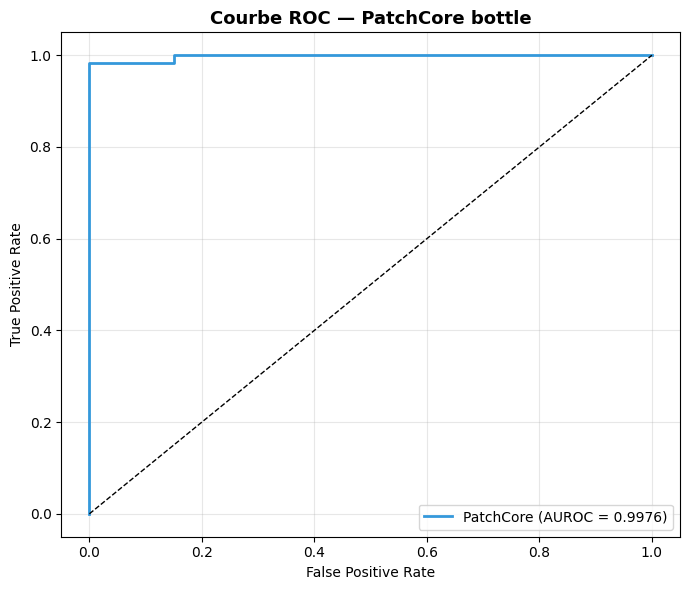

✅ Courbe ROC sauvegardée


In [28]:
# Courbe ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'PatchCore (AUROC = {auroc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — PatchCore bottle', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('patchcore_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Courbe ROC sauvegardée')

## 7. Heatmaps d'anomalies

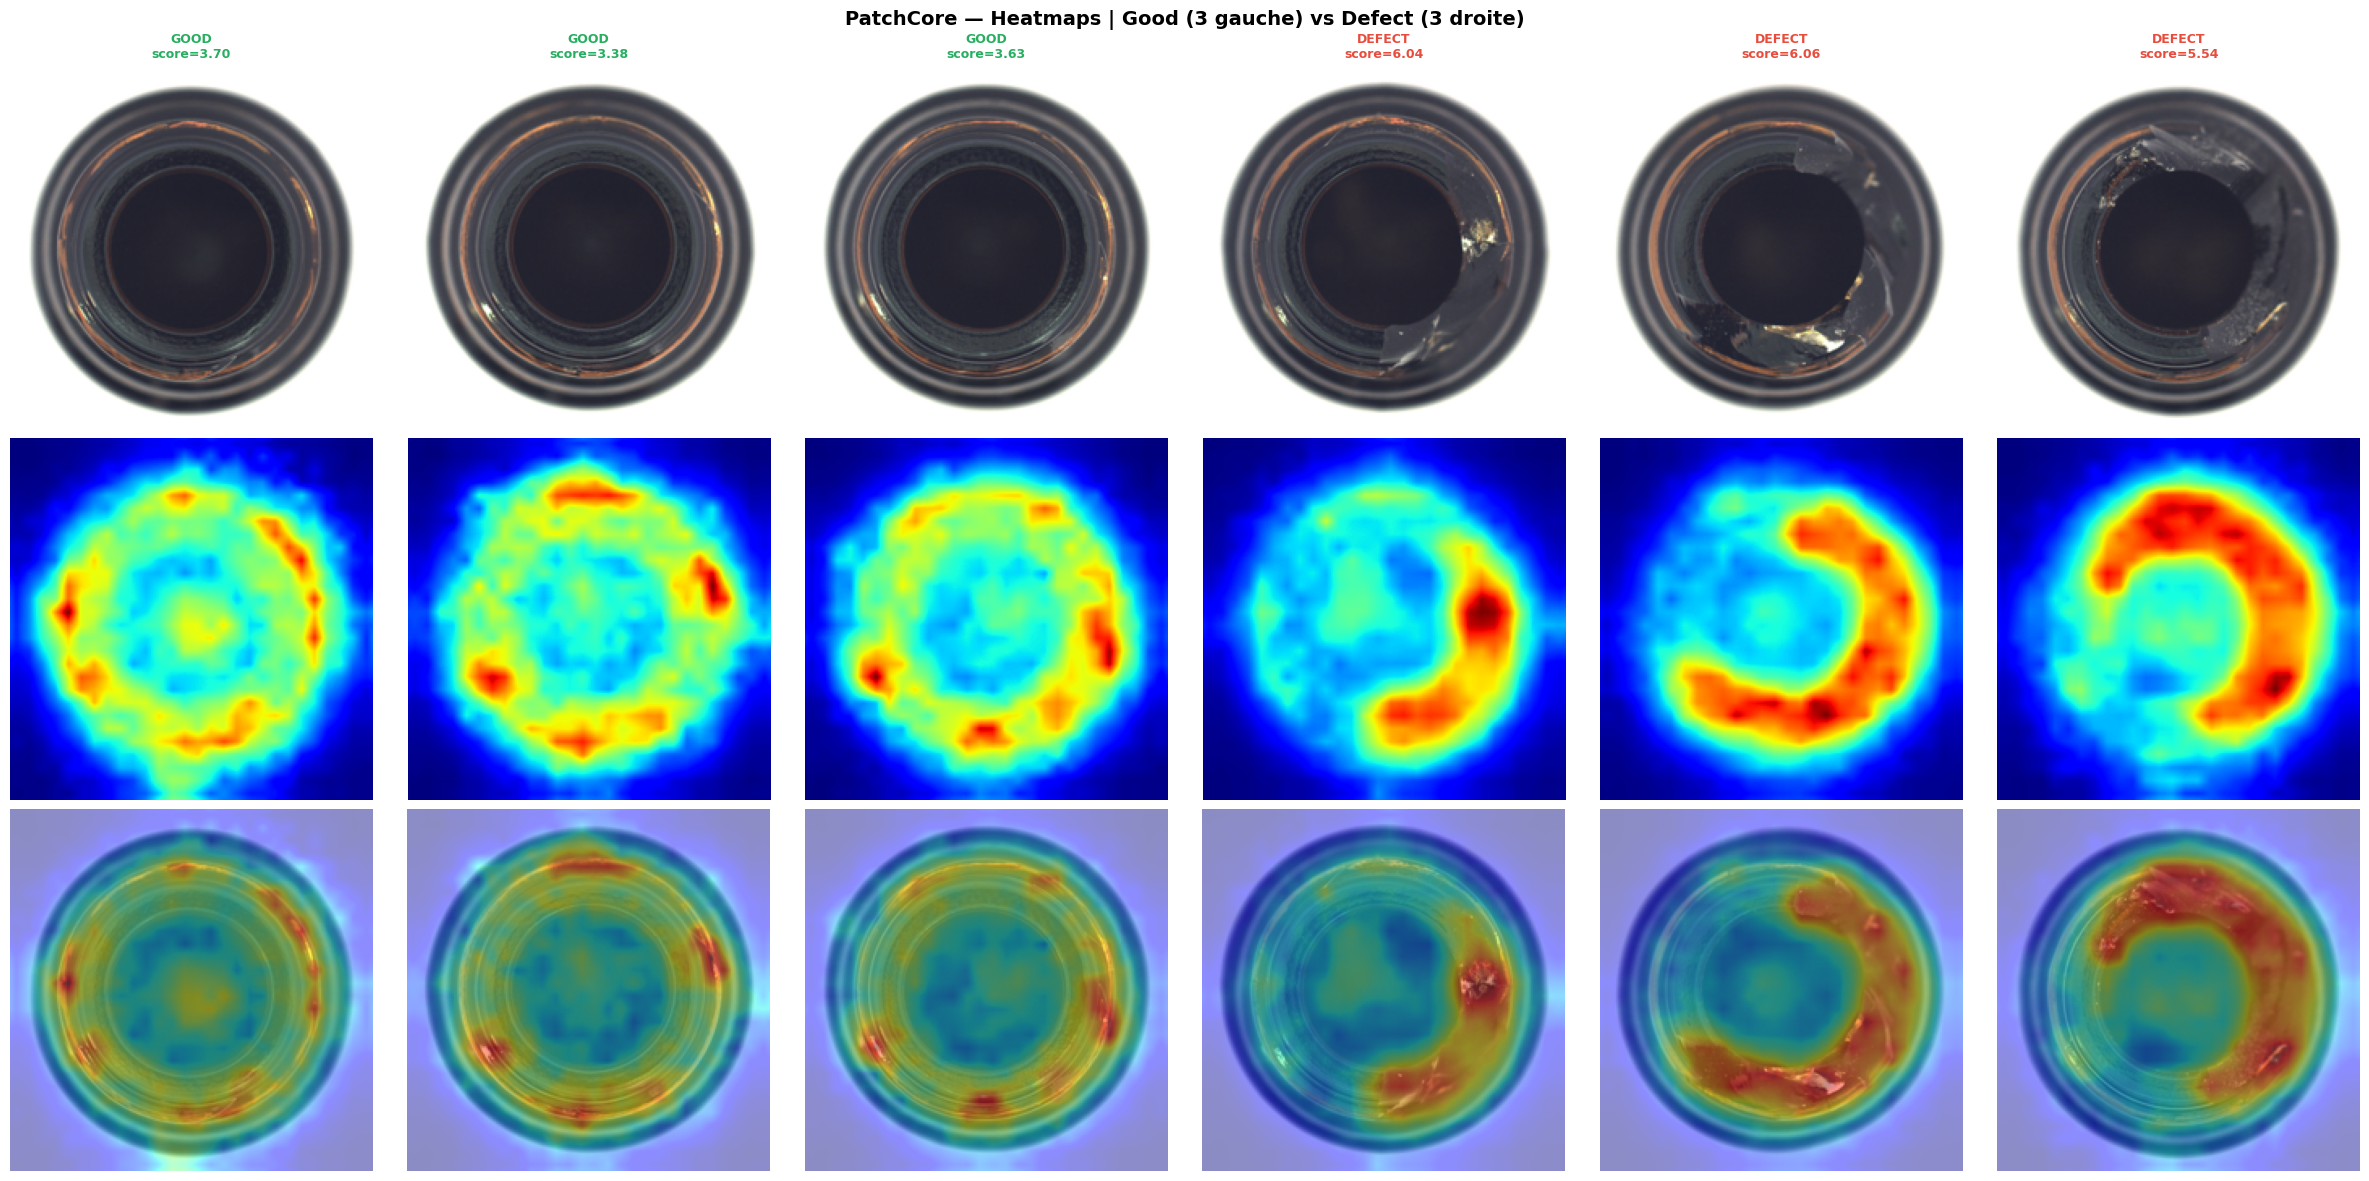

✅ Heatmaps sauvegardées


In [29]:
from skimage.transform import resize as sk_resize

def visualize_sample(img_path, score, heatmap, label, ax_row, col):
    img_orig = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    heat_up  = sk_resize(heatmap, (224, 224), order=1)
    heat_norm = (heat_up - heat_up.min()) / (heat_up.max() - heat_up.min() + 1e-8)
    heat_rgb  = cm.jet(heat_norm)[:, :, :3]
    overlay   = np.clip(0.55 * img_orig/255 + 0.45 * heat_rgb, 0, 1)

    title_color = '#e74c3c' if label == 1 else '#27ae60'
    title_text  = f'{"DEFECT" if label==1 else "GOOD"}\nscore={score:.2f}'

    ax_row[0][col].imshow(img_orig)
    ax_row[0][col].set_title(title_text, fontsize=8, fontweight='bold', color=title_color)
    ax_row[0][col].axis('off')

    ax_row[1][col].imshow(heat_rgb)
    ax_row[1][col].axis('off')

    ax_row[2][col].imshow(overlay)
    ax_row[2][col].axis('off')

# Sélectionner 3 good + 3 defect
good_idx   = random.sample(list(np.where(labels==0)[0]), 3)
defect_idx = random.sample(list(np.where(labels==1)[0]), 3)
selected   = good_idx + defect_idx

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
fig.suptitle('PatchCore — Heatmaps | Good (3 gauche) vs Defect (3 droite)',
             fontsize=14, fontweight='bold')

row_labels = ['Image originale', 'Heatmap anomalie', 'Overlay']
for i, rl in enumerate(row_labels):
    axes[i, 0].set_ylabel(rl, fontsize=10, fontweight='bold')

ax_rows = [axes[:, :], None, None]

for col_idx, idx in enumerate(selected):
    img_path = test_imgs[idx]
    score    = scores[idx]
    heatmap  = heatmaps[idx]
    label    = labels[idx]

    img_orig  = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    heat_up   = sk_resize(heatmap, (224, 224), order=1)
    heat_norm = (heat_up - heat_up.min()) / (heat_up.max() - heat_up.min() + 1e-8)
    heat_rgb  = cm.jet(heat_norm)[:, :, :3]
    overlay   = np.clip(0.55 * img_orig/255 + 0.45 * heat_rgb, 0, 1)

    title_color = '#e74c3c' if label == 1 else '#27ae60'
    title_text  = f'{"DEFECT" if label==1 else "GOOD"}\nscore={score:.2f}'

    axes[0, col_idx].imshow(img_orig)
    axes[0, col_idx].set_title(title_text, fontsize=9, fontweight='bold', color=title_color)
    axes[0, col_idx].axis('off')

    axes[1, col_idx].imshow(heat_rgb)
    axes[1, col_idx].axis('off')

    axes[2, col_idx].imshow(overlay)
    axes[2, col_idx].axis('off')

plt.tight_layout()
plt.savefig('patchcore_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmaps sauvegardées')

## 8. Sauvegarde sur Drive

In [30]:
import shutil

# Sauvegarder la Memory Bank
mb_path = MODELS_PATH / 'memory_bank.pt'
torch.save({
    'memory_bank' : memory_bank,
    'category'    : CATEGORY,
    'backbone'    : 'wide_resnet50_2',
    'layers'      : ['layer2', 'layer3'],
    'auroc'       : auroc,
    'best_f1'     : best_f1,
    'best_thresh' : best_thresh,
}, mb_path)

# Sauvegarder les visualisations
shutil.copy2('patchcore_roc.png',      MODELS_PATH / 'roc_curve.png')
shutil.copy2('patchcore_heatmaps.png', MODELS_PATH / 'heatmaps.png')

print(f'✅ Sauvegardé sur Drive : {MODELS_PATH}')
print(f'   memory_bank.pt : {mb_path.stat().st_size / 1e6:.1f} MB')

✅ Sauvegardé sur Drive : /content/drive/MyDrive/defect-vision/models/patchcore_bottle
   memory_bank.pt : 100.7 MB


## 9. Push sur HuggingFace Hub

In [ ]:
from huggingface_hub import HfApi, login

# ⚠️ Ne jamais committer ce token sur GitHub !
HF_TOKEN    = 'TON_TOKEN_HUGGINGFACE'  # remplace ici
HF_USERNAME = 'Chasston'
REPO_NAME   = 'defect-vision-patchcore-bottle'

login(token=HF_TOKEN)
api     = HfApi()
repo_id = f'{HF_USERNAME}/{REPO_NAME}'

api.create_repo(repo_id=repo_id, repo_type='model', exist_ok=True)
print(f'✅ Repo : {repo_id}')

✅ Repo : Chasston/defect-vision-patchcore-bottle


In [33]:
readme = f"""---
tags:
- anomaly-detection
- computer-vision
- patchcore
- defect-detection
- industrial
datasets:
- mvtec-ad
---

# DefectVision — PatchCore Anomaly Detection (bottle)

PatchCore implemented from scratch with PyTorch on MVTec AD.

## Why PatchCore over YOLOv8?
| Model | Approach | Key Metric |
|-------|----------|------------|
| YOLOv8n | Supervised | mAP50 = 0.09 |
| PatchCore | Unsupervised | AUROC = {auroc:.4f} |

YOLOv8 struggles with MVTec AD because defect images are scarce.
PatchCore trains on normal images only and generalizes to unseen defects.

## Architecture
- **Backbone**: WideResNet50 (ImageNet pretrained)
- **Layers**: layer2 + layer3 → 1536-dim patch features
- **Memory Bank**: coreset 10% of train patches
- **Scoring**: max nearest-neighbor distance (k=9)

## Metrics — bottle
- **AUROC** : {auroc:.4f}
- **Best F1**: {best_f1:.4f}

## Usage
```python
import torch
from huggingface_hub import hf_hub_download

path = hf_hub_download(repo_id='{repo_id}', filename='memory_bank.pt')
data = torch.load(path)
memory_bank = data['memory_bank']
```

## Author
[{HF_USERNAME}](https://huggingface.co/{HF_USERNAME})
"""

with open('/content/README_pc.md', 'w') as f:
    f.write(readme)

files_to_upload = [
    (str(mb_path),                   'memory_bank.pt'),
    (str(MODELS_PATH / 'roc_curve.png'), 'roc_curve.png'),
    (str(MODELS_PATH / 'heatmaps.png'),  'heatmaps.png'),
    ('/content/README_pc.md',            'README.md'),
]

for local_path, hf_name in files_to_upload:
    if Path(local_path).exists():
        api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = hf_name,
            repo_id         = repo_id,
            repo_type       = 'model',
        )
        print(f'  ✅ {hf_name}')

print(f'\n🎉 https://huggingface.co/{repo_id}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ore_bottle/memory_bank.pt:   1%|          |  591kB /  101MB            

  ✅ memory_bank.pt
  ✅ roc_curve.png


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...hcore_bottle/heatmaps.png:  89%|########9 | 3.67MB / 4.12MB            

  ✅ heatmaps.png
  ✅ README.md

🎉 https://huggingface.co/Chasston/defect-vision-patchcore-bottle


## ✅ Résumé

| Info | Valeur |
|------|--------|
| Modèle | PatchCore from scratch |
| Backbone | WideResNet50 (ImageNet) |
| Dataset | MVTec AD — bottle |
| Drive | `/defect-vision/models/patchcore_bottle/` |
| HuggingFace | `Chasston/defect-vision-patchcore-bottle` |
| Prochain | `05_api_gradio.ipynb` → FastAPI + Gradio |

**Prochaine étape** : Créer l'API FastAPI + interface Gradio pour déployer les modèles.